In [7]:
import pandas as pd

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


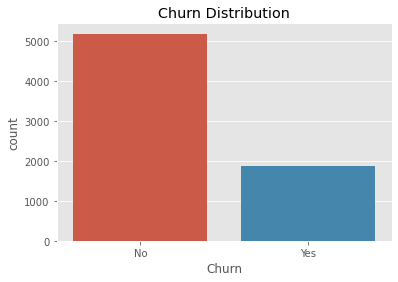

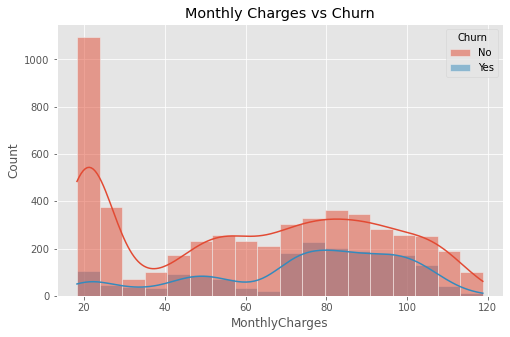

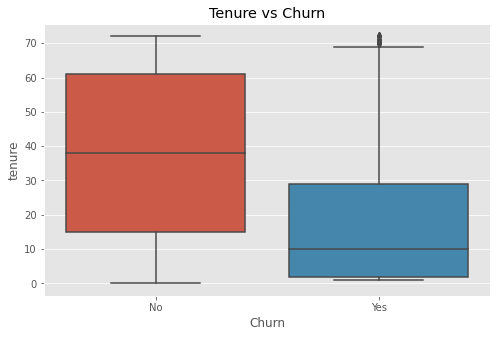

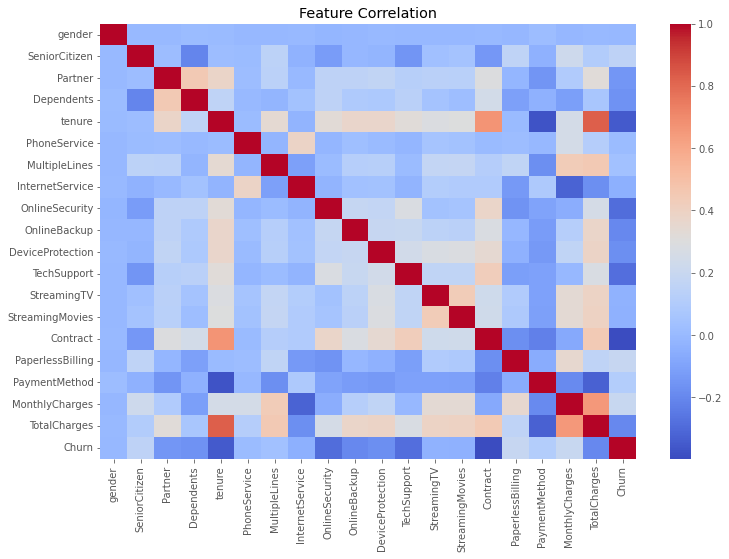

In [ ]:
# =========================
# AI-Powered Churn System
# Complete End-to-End Code
# =========================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

plt.style.use("ggplot")


# =========================
# 1. LOAD DATASET (URL)
# =========================

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Dataset Shape:", df.shape)
display(df.head())


# =========================
# 2. DATA CLEANING
# =========================

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)
df.drop("customerID", axis=1, inplace=True)


# =========================
# 3. EDA (BASIC VISUALS)
# =========================

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(data=df, x="MonthlyCharges", hue="Churn", kde=True)
plt.title("Monthly Charges vs Churn")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure vs Churn")
plt.show()


# =========================
# 4. ENCODING CATEGORICAL
# =========================

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])


# =========================
# 5. CORRELATION HEATMAP
# =========================

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()


# =========================
# 6. SPLIT DATA
# =========================

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# =========================
# 7. MODEL TRAINING
# =========================

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)


# =========================
# 8. PREDICTIONS
# =========================

y_pred = model.predict(X_test)

print("\nAccuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nROC-AUC:", round(roc_auc_score(y_test, model.predict_proba(X_test)[:,1]), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


# =========================
# 9. CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# =========================
# 10. FEATURE IMPORTANCE
# =========================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importance.head(10), x="Importance", y="Feature")
plt.title("Top Churn Drivers")
plt.show()


# =========================
# 11. CHURN RISK SCORING
# =========================

risk_scores = model.predict_proba(X_test)[:,1]

risk_df = X_test.copy()
risk_df["Churn_Probability"] = risk_scores


# =========================
# 12. RISK CATEGORIZATION
# =========================

def risk_level(x):
    if x >= 0.75:
        return "High Risk"
    elif x >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

risk_df["Risk_Level"] = risk_df["Churn_Probability"].apply(risk_level)


# =========================
# 13. RISK DASHBOARD
# =========================

plt.figure(figsize=(6,4))
sns.countplot(data=risk_df, x="Risk_Level", palette="Set2")
plt.title("Churn Risk Distribution")
plt.show()


# =========================
# 14. HIGH RISK CUSTOMERS
# =========================

high_risk = risk_df[risk_df["Risk_Level"] == "High Risk"]

print("High Risk Customers:", high_risk.shape[0])
display(high_risk.head())


# =========================
# 15. EXPORT RESULTS
# =========================

high_risk.to_csv("high_risk_customers.csv", index=False)
print("\nSaved: high_risk_customers.csv")


# =========================
# END OF PROJECT
# =========================